**1. Mount Google Drive**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**2. Lokasi Dataset**

In [3]:
dataset_path = "/content/drive/MyDrive/machine_learning/TrashType_Image_Dataset"

**3. Memastikan Dataset Berhasil Ditemukan**

In [4]:
import os

print(os.path.exists(dataset_path))

True


**4. Menampilkan Kelas Dataset**

In [5]:
print(os.listdir(dataset_path))

['trash', 'glass', 'paper', 'metal', 'cardboard', 'plastic']


**5. Import Library**

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

**6. Data Preprocessing dan Data Augmentation**

In [7]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

**7. Memuat Dataset Training dan Validation**

In [8]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 2025 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


**8. Membangun Model Transfer Learning (MobileNetV2)**

In [9]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze semua layer
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


**9. Menambahkan Layer Klasifikasi (Classifier)**

In [10]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

**10. Compile Model**

In [11]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**11. Konfigurasi Callback EarlyStopping**

In [19]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [12]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

**12. Konfigurasi Callback EarlyStopping**

In [13]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

**13. Proses Pelatihan Model (Training Model)**

In [14]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1464s 23s/step - accuracy: 0.3941 - loss: 1.5407 - val_accuracy: 0.6441 - val_loss: 1.0385
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.5793 - loss: 1.1162 - val_accuracy: 0.7038 - val_loss: 0.8701
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.6602 - loss: 0.9136 - val_accuracy: 0.7396 - val_loss: 0.7671
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.6790 - loss: 0.8421 - val_accuracy: 0.7336 - val_loss: 0.7261
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.7170 - loss: 0.7577 - val_accuracy: 0.7515 - val_loss: 0.6935
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.7333 - loss: 0.7188 - val_accuracy: 0.7535 - val_loss: 0.6801
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.7511 - loss: 0.6782 - val_accuracy: 0.7674 - val_loss: 0.6503
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.7610 - loss: 0.6424 - val_accuracy: 0.7714 -

**14. Evaluasi Kinerja Model**

In [15]:
loss, accuracy = model.evaluate(validation_generator)

print("Validation Loss :", loss)
print("Validation Accuracy :", accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.8032 - loss: 0.5575
Validation Loss : 0.5574555397033691
Validation Accuracy : 0.8031809329986572


**15. Visualisasi Grafik Akurasi Model**

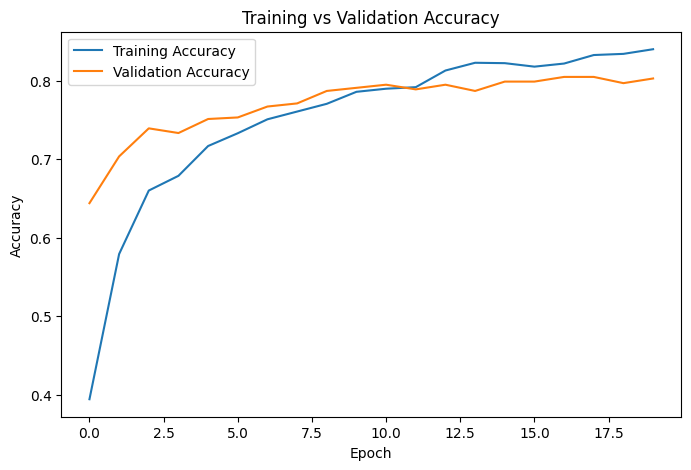

In [16]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

**16. Visualisasi Grafik Loss Model**

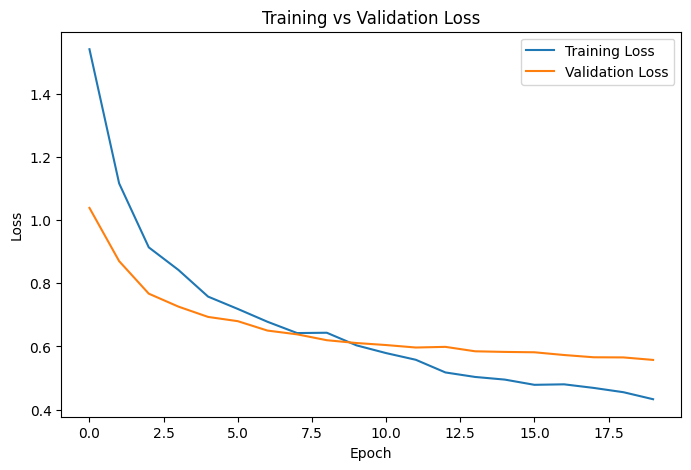

In [17]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

**17. Analisis Overfitting Model**

In [18]:
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("Training Accuracy :", train_acc)
print("Validation Accuracy :", val_acc)

difference = train_acc - val_acc

print("Selisih :", difference)

if difference > 0.10:
    print("Model mengalami OVERFITTING")
else:
    print("Model TIDAK mengalami OVERFITTING")

Training Accuracy : 0.8404937982559204
Validation Accuracy : 0.8031809329986572
Selisih : 0.037312865257263184
Model TIDAK mengalami OVERFITTING
